## Submissions for speakers dataset

In [161]:
from preprocessing_class import Preprocessing, load_pres_test, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Format submission
```
submission-pres-X.csv
```

In [163]:
# load dataset train
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")
alltxt, alllabs = np.array(alltxt), np.array(alllabs)
alllabs = np.where(alllabs == 1, 0, 1)

In [3]:
# load dataset test
alltxt_test = load_pres_test("Test_set/corpus.tache1.test.utf8")
alltxt_test = np.array(alltxt_test)

In [164]:
alltxt_test.shape, alltxt.shape

((27162,), (57413,))

In [165]:
# function to use
from sklearn.metrics import f1_score

def save_submission(predictions, number):
    filename = f"Test_submission/pres/submission-pres-{number}.csv"
    np.savetxt(filename, predictions, delimiter="\n", fmt='%f')

def model_prediction(model, vectorizer, X_train, y_train, X_test, number = 'test'):
    # vectorizing
    vect_train = vectorizer.fit_transform(X_train)
    vect_test = vectorizer.transform(X_test)

    # scaling ?

    model.fit(vect_train, y_train)

    # predictions
    y_pred_train = model.predict(vect_train)
    y_pred_prob_train = model.predict_proba(vect_train)

    y_pred_prob = model.predict_proba(vect_test)
    predictions = y_pred_prob[:,0]

    # prints
    dist = np.where(predictions < 0.5, 'C', 'M')
    val, count = np.unique(dist, return_counts=True) # seems like unbalanced, or biaised

    print("F1 score of train",f1_score(y_train,y_pred_train))
    print("Distribution of test", val, count)

    # saving
    save_submission(predictions, number)

In [166]:
def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.99, min_df=0.01, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

def build_model(name="kmeans", n_clusters = 2, max_iter = 1000, penalty='l2', loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter) 

### Submission 1 (number 2)

In [6]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [7]:
final_stopwords_list = stopwords.words('french') 
vectoriser = build_vectorizer(name="tfidf", stop_words=final_stopwords_list, max_features=None, preprocessor=prep)

# train on the sub train
vect_train = vectoriser.fit_transform(alltxt)
vect_test = vectoriser.transform(alltxt_test)

In [8]:
# model logistic regression
model = build_model(name="logreg")

In [9]:
model.fit(vect_train,alllabs)

# preds
y_pred_train = model.predict(vect_train)
ypred_train_prob = model.predict_proba(vect_train) # probas for ROC

y_pred = model.predict(vect_test)
y_pred_prob = model.predict_proba(vect_test)

In [ ]:
from sklearn.metrics import average_precision_score, f1_score

average_precision_score(alllabs, y_pred_train, average="macro"), average_precision_score(alllabs, y_pred_train, average="weighted")

(0.8763620445868716, 0.8763620445868716)

In [15]:
f1_score(alllabs, y_pred_train, average="macro"), f1_score(alllabs, y_pred_train, average="weighted"),

(0.5289097284272443, 0.8263233694731392)

In [28]:
# dim 0 = -1, dim 1 = 1
# M = -1, C = 1
ypred_train_prob # keep dim 0  

array([[0.61477151, 0.38522849],
       [0.13165143, 0.86834857],
       [0.08209623, 0.91790377],
       ...,
       [0.02687995, 0.97312005],
       [0.31412181, 0.68587819],
       [0.07823031, 0.92176969]], shape=(57413, 2))

In [70]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

In [71]:
model = build_model(name="logreg")

final_stopwords_list = stopwords.words('french') 
vectoriser = build_vectorizer(name="tfidf", stop_words=final_stopwords_list, max_features=None, preprocessor=prep)

In [ ]:
model_prediction(model, vectoriser, alltxt, alllabs, alltxt_test, number=1)

F1 score of train 0.9319453309803627
Distribution of test ['C' 'M'] [26772   390]


In [3]:
(np.array([26772 ,390]))/np.sum(np.array([26772 ,390]))

array([0.98564171, 0.01435829])

### Submission 2 Transformers (ran on PPTI)

In [6]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score
import torch

In [7]:
# loading the model and tokenizing our text
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-cased') # smaller

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# loading tokenized train and validation

data = torch.load("train_tokens_dist.pt")
input_ids = data["input_ids"]
attention_masks = data["attention_masks"]

data = torch.load("test_tokens_dist.pt")
input_ids_test = data["input_ids"]
attention_masks_test = data["attention_masks"]

# train version

input_ids_train = torch.cat([input_ids, input_ids_test], dim=0)
attention_masks_train = torch.cat([attention_masks, attention_masks_test], dim=0)

In [ ]:
# tokenizing test set

maxL = 512 # Max length of the sequence

inputs_tokens_test = []
attention_masks_test = []

for i in range(len(alltxt_test)):
    if(i%2500==0):
        print(i)
    string_tokenized = tokenizer(alltxt_test[i], return_tensors="pt",
                                        add_special_tokens=True,  # add '[CLS]' and '[SEP]'
                                        max_length=maxL,  # set max length
                                        truncation=True,  # truncate longer messages
                                        #pad_to_max_length=True
                                        padding='max_length',  # add padding
                                        return_attention_mask=True)

    inputs_tokens_test.append(string_tokenized['input_ids'])
    attention_masks_test.append(string_tokenized['attention_mask'])

# convert into one big tensor
input_ids_test = torch.cat(inputs_tokens_test, dim=0)
attention_masks_test = torch.cat(attention_masks_test, dim=0)

0
2500
5000
7500
10000
12500
15000
17500
20000
22500
25000


In [9]:
# torch.save({
#     "input_ids": input_ids_test,
#     "attention_masks": attention_masks_test
# }, "pred_test_tokens_dist.pt")

data = torch.load("pred_test_tokens_dist.pt")
input_ids_test = data["input_ids"]
attention_masks_test = data["attention_masks"]

In [28]:
counts/np.sum(counts)

array([0.13103304, 0.86896696])

In [10]:
alllabs = np.where(alllabs == -1, 0, alllabs)
val, counts = np.unique(alllabs, return_counts = True)

weights = 1/counts
print(val, counts)

[0 1] [ 7523 49890]


In [11]:
# labels to torch
y_train_tens = torch.tensor(alllabs)

# Convert labels from -1/1 → 0/1 (BCE/CE convention)
y_train_tens = ((y_train_tens + 1) // 2).long() 

np.unique(alllabs), np.unique(y_train_tens)

(array([0, 1]), array([0, 1]))

In [ ]:
# dataset
from torch.utils.data import TensorDataset, random_split, DataLoader, RandomSampler, SequentialSampler


dataset_train = TensorDataset(input_ids_train,  attention_masks_train, y_train_tens)
dataset_test = TensorDataset(input_ids_test,  attention_masks_test)

train_dataloader = DataLoader(
    dataset_train,
    batch_size=8,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset_test,
    batch_size=8,
    shuffle=False # f
)

In [13]:
# loading model
from transformers import DistilBertForSequenceClassification
model = DistilBertForSequenceClassification.from_pretrained("bert_dist_cache/models--distilbert-base-cased/snapshots/6ea81172465e8b0ad3fddeed32b986cdcdcffcf0")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 489.42it/s]
DistilBertForSequenceClassification LOAD REPORT from: bert_dist_cache/models--distilbert-base-cased/snapshots/6ea81172465e8b0ad3fddeed32b986cdcdcffcf0
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
from torch import device
import gc, torch

gc.collect()
torch.cuda.empty_cache()

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# dev = torch.device("cpu")
model.to(dev)
dev

device(type='cuda')

In [21]:
from torch.nn import CrossEntropyLoss

class_weights = torch.tensor(weights, dtype=torch.float).to(dev)
loss_fn = CrossEntropyLoss(weight=class_weights)

Using loss_fn here ! not the model !

In [ ]:
import gc
import json
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

optimizer = optim.Adam(model.parameters(), lr=2e-5)
epochs = 1

model.to(dev)
epochs_evolution = {}

# ── Training ─────────────────────────────────────────────────────────────────
for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []
    all_train_logits = []

    for i, batch in enumerate(train_dataloader):
        print("batch", i)
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        model.zero_grad()

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask,
            # labels=b_labels
        )
        # loss = outputs.loss
        logits = outputs.logits
        loss = loss_fn(logits, b_labels)

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())
        all_train_logits.append(logits.detach().cpu())

        del b_input_ids, b_attention_mask, b_labels
        del outputs, loss, logits, preds
        torch.cuda.empty_cache()
        gc.collect()

    avg_train_loss = total_loss / len(train_dataloader)

    # Training metrics
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    all_logits_tensor = torch.cat(all_train_logits, dim=0)
    train_probs = torch.softmax(all_logits_tensor, dim=1)[:, 1].numpy()
    train_auc = roc_auc_score(all_train_labels, train_probs)
    train_ap  = average_precision_score(all_train_labels, train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")

    epochs_evolution[f"epoch_{epoch+1}"] = {   # fixed key to track each epoch
        "loss": avg_train_loss,
        "f1": train_f1,
        "precision": train_precision,
        "recall": train_recall,
        "auc": train_auc,
        "ap": train_ap
    }

    del all_train_logits, all_logits_tensor, train_probs
    del all_train_preds, all_train_labels
    torch.cuda.empty_cache()
    gc.collect()

json.dump(epochs_evolution, open("train_res.json", "w"))
print("Training metrics saved to train_res.json")

# ── Prediction on unlabeled test set ─────────────────────────────────────────
model.eval()
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask = [t.to(dev) for t in batch]  # no labels

        outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)[:, 1]
        preds   = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del b_input_ids, b_attention_mask
        del outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()

# Save predictions and probabilities
np.save("PRED_test_preds.npy", np.array(all_preds))
np.save("PRED_test_probs.npy", np.array(all_probs))
print(f"Predictions saved — {len(all_preds)} samples")
print(f"Class distribution: { {v: int((np.array(all_preds)==v).sum()) for v in np.unique(all_preds)} }")

# ── Final cleanup ─────────────────────────────────────────────────────────────
del all_preds, all_probs
torch.cuda.empty_cache()
gc.collect()

In [22]:
# for my GPU
import gc
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# ---------------------- Setup ----------------------
model.to(dev)
optimizer = optim.Adam(model.parameters(), lr=2e-4)
scaler = torch.amp.GradScaler("cuda")  # mixed precision
epochs = 1
epochs_evolution = {}

# Adjust batch size for your RTX memory
# Try batch_size=8 first; reduce if OOM occurs

# ---------------------- Training ----------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []

    for i, batch in enumerate(train_dataloader):
        print('batch', i)
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, b_labels)

        # Backward with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())

        # Clean up
        del b_input_ids, b_attention_mask, b_labels, outputs, logits, preds, loss
        torch.cuda.empty_cache()
        gc.collect()

    # Metrics
    avg_train_loss = total_loss / len(train_dataloader)
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    # Optional: compute AUC/AP batch-wise without storing all logits
    # Here we approximate using predictions
    all_train_probs = np.array(all_train_preds)  # safer: compute on logits if needed
    train_auc = roc_auc_score(all_train_labels, all_train_probs)
    train_ap  = average_precision_score(all_train_labels, all_train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")

    epochs_evolution[f"epoch_{epoch+1}"] = {
        "loss": avg_train_loss,
        "f1": train_f1,
        "precision": train_precision,
        "recall": train_recall,
        "auc": train_auc,
        "ap": train_ap
    }

# Save metrics
json.dump(epochs_evolution, open("train_res.json", "w"))
print("Training metrics saved to train_res.json")

# ---------------------- Inference ----------------------
model.eval()
all_preds, all_probs = [], []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask = [t.to(dev) for t in batch]

        with torch.amp.autocast("cuda"):
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del b_input_ids, b_attention_mask, outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()

# Save predictions
np.save("PRED_test_preds.npy", np.array(all_preds))
np.save("PRED_test_probs.npy", np.array(all_probs))
print(f"Predictions saved — {len(all_preds)} samples")
print(f"Class distribution: { {v: int((np.array(all_preds)==v).sum()) for v in np.unique(all_preds)} }")

# Cleanup
del all_preds, all_probs
torch.cuda.empty_cache()
gc.collect()

batch 0


/tmp/ipykernel_1135965/393742922.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26
batch 27
batch 28
batch 29
batch 30
batch 31
batch 32
batch 33
batch 34
batch 35
batch 36
batch 37
batch 38
batch 39
batch 40
batch 41
batch 42
batch 43
batch 44
batch 45
batch 46
batch 47
batch 48
batch 49
batch 50
batch 51
batch 52
batch 53
batch 54
batch 55
batch 56
batch 57
batch 58
batch 59
batch 60
batch 61
batch 62
batch 63
batch 64
batch 65
batch 66
batch 67
batch 68
batch 69
batch 70
batch 71
batch 72
batch 73
batch 74
batch 75
batch 76
batch 77
batch 78
batch 79
batch 80
batch 81
batch 82
batch 83
batch 84
batch 85
batch 86
batch 87
batch 88
batch 89
batch 90
batch 91
batch 92
batch 93
batch 94
batch 95
batch 96
batch 97
batch 98
batch 99
batch 100
batch 101
batch 102
batch 103
batch 104
batch 105
batch 106
batch 107
batch 108
batch 109
batch 110
batch 11

0

In [ ]:
# for my GPU, 3 epochs train
import gc
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# ---------------------- Setup ----------------------
model.to(dev)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
scaler = torch.amp.GradScaler("cuda")  # mixed precision
epochs = 3
epochs_evolution = {}

# Adjust batch size for your RTX memory
# Try batch_size=8 first; reduce if OOM occurs

# ---------------------- Training ----------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []

    for i, batch in enumerate(train_dataloader):
        print('batch', i)
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, b_labels)

        # Backward with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())

        # Clean up
        del b_input_ids, b_attention_mask, b_labels, outputs, logits, preds, loss
        torch.cuda.empty_cache()
        gc.collect()

    # Metrics
    avg_train_loss = total_loss / len(train_dataloader)
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    # Optional: compute AUC/AP batch-wise without storing all logits
    # Here we approximate using predictions
    all_train_probs = np.array(all_train_preds)  # safer: compute on logits if needed
    train_auc = roc_auc_score(all_train_labels, all_train_probs)
    train_ap  = average_precision_score(all_train_labels, all_train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")

    epochs_evolution[f"epoch_{epoch+1}"] = {
        "loss": avg_train_loss,
        "f1": train_f1,
        "precision": train_precision,
        "recall": train_recall,
        "auc": train_auc,
        "ap": train_ap
    }

# Save metrics
json.dump(epochs_evolution, open("train_res_3.json", "w"))
print("Training metrics saved to train_res_3.json")

# ---------------------- Inference ----------------------
model.eval()
all_preds, all_probs = [], []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask = [t.to(dev) for t in batch]

        with torch.amp.autocast("cuda"):
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del b_input_ids, b_attention_mask, outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()

# Save predictions
np.save("PRED_test_preds_3.npy", np.array(all_preds))
np.save("PRED_test_probs_3.npy", np.array(all_probs))
print(f"Predictions saved — {len(all_preds)} samples")
print(f"Class distribution: { {v: int((np.array(all_preds)==v).sum()) for v in np.unique(all_preds)} }")

# Cleanup
del all_preds, all_probs
torch.cuda.empty_cache()
gc.collect()

batch 0


/tmp/ipykernel_1135965/3243061167.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26
batch 27
batch 28
batch 29
batch 30
batch 31
batch 32
batch 33
batch 34
batch 35
batch 36
batch 37
batch 38
batch 39
batch 40
batch 41
batch 42
batch 43
batch 44
batch 45
batch 46
batch 47
batch 48
batch 49
batch 50
batch 51
batch 52
batch 53
batch 54
batch 55
batch 56
batch 57
batch 58
batch 59
batch 60
batch 61
batch 62
batch 63
batch 64
batch 65
batch 66
batch 67
batch 68
batch 69
batch 70
batch 71
batch 72
batch 73
batch 74
batch 75
batch 76
batch 77
batch 78
batch 79
batch 80
batch 81
batch 82
batch 83
batch 84
batch 85
batch 86
batch 87
batch 88
batch 89
batch 90
batch 91
batch 92
batch 93
batch 94
batch 95
batch 96
batch 97
batch 98
batch 99
batch 100
batch 101
batch 102
batch 103
batch 104
batch 105
batch 106
batch 107
batch 108
batch 109
batch 110
batch 11

/tmp/ipykernel_1135965/3243061167.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26
batch 27
batch 28
batch 29
batch 30
batch 31
batch 32
batch 33
batch 34
batch 35
batch 36
batch 37
batch 38
batch 39
batch 40
batch 41
batch 42
batch 43
batch 44
batch 45
batch 46
batch 47
batch 48
batch 49
batch 50
batch 51
batch 52
batch 53
batch 54
batch 55
batch 56
batch 57
batch 58
batch 59
batch 60
batch 61
batch 62
batch 63
batch 64
batch 65
batch 66
batch 67
batch 68
batch 69
batch 70
batch 71
batch 72
batch 73
batch 74
batch 75
batch 76
batch 77
batch 78
batch 79
batch 80
batch 81
batch 82
batch 83
batch 84
batch 85
batch 86
batch 87
batch 88
batch 89
batch 90
batch 91
batch 92
batch 93
batch 94
batch 95
batch 96
batch 97
batch 98
batch 99
batch 100
batch 101
batch 102
batch 103
batch 104
batch 105
batch 106
batch 107
batch 108
batch 109
batch 110
batch 11

/tmp/ipykernel_1135965/3243061167.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9
batch 10
batch 11
batch 12
batch 13
batch 14
batch 15
batch 16
batch 17
batch 18
batch 19
batch 20
batch 21
batch 22
batch 23
batch 24
batch 25
batch 26
batch 27
batch 28
batch 29
batch 30
batch 31
batch 32
batch 33
batch 34
batch 35
batch 36
batch 37
batch 38
batch 39
batch 40
batch 41
batch 42
batch 43
batch 44
batch 45
batch 46
batch 47
batch 48
batch 49
batch 50
batch 51
batch 52
batch 53
batch 54
batch 55
batch 56
batch 57
batch 58
batch 59
batch 60
batch 61
batch 62
batch 63
batch 64
batch 65
batch 66
batch 67
batch 68
batch 69
batch 70
batch 71
batch 72
batch 73
batch 74
batch 75
batch 76
batch 77
batch 78
batch 79
batch 80
batch 81
batch 82
batch 83
batch 84
batch 85
batch 86
batch 87
batch 88
batch 89
batch 90
batch 91
batch 92
batch 93
batch 94
batch 95
batch 96
batch 97
batch 98
batch 99
batch 100
batch 101
batch 102
batch 103
batch 104
batch 105
batch 106
batch 107
batch 108
batch 109
batch 110
batch 11

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 3/3 - Loss: 0.6727 | F1: 0.4649 | Precision: 0.4345 | Recall: 0.5000 | AUC: 0.5000 | AP: 0.8690
Training metrics saved to train_res_3.json
Predictions saved — 27162 samples
Class distribution: {np.int64(1): 27162}


0

In [ ]:
# for my GPU, 3 epochs train
import gc
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# ---------------------- Setup ----------------------
model.to(dev)
optimizer = optim.Adam(model.parameters(), lr=2e-4)
scaler = torch.amp.GradScaler("cuda")  # mixed precision
epochs = 3
epochs_evolution = {}

# Adjust batch size for your RTX memory
# Try batch_size=8 first; reduce if OOM occurs

# ---------------------- Training ----------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []

    for i, batch in enumerate(train_dataloader):
        print('batch', i)
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
            logits = outputs.logits
            loss = outputs.loss  # use built-in loss for better stability with mixed precision

        # Backward with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())

        # Clean up
        del b_input_ids, b_attention_mask, b_labels, outputs, logits, preds, loss
        torch.cuda.empty_cache()
        gc.collect()

    # Metrics
    avg_train_loss = total_loss / len(train_dataloader)
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    # Optional: compute AUC/AP batch-wise without storing all logits
    # Here we approximate using predictions
    all_train_probs = np.array(all_train_preds)  # safer: compute on logits if needed
    train_auc = roc_auc_score(all_train_labels, all_train_probs)
    train_ap  = average_precision_score(all_train_labels, all_train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")

    epochs_evolution[f"epoch_{epoch+1}"] = {
        "loss": avg_train_loss,
        "f1": train_f1,
        "precision": train_precision,
        "recall": train_recall,
        "auc": train_auc,
        "ap": train_ap
    }

# Save metrics
json.dump(epochs_evolution, open("train_res_3.json", "w"))
print("Training metrics saved to train_res_3.json")

# ---------------------- Inference ----------------------
model.eval()
all_preds, all_probs = [], []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask = [t.to(dev) for t in batch]

        with torch.amp.autocast("cuda"):
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del b_input_ids, b_attention_mask, outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()

# Save predictions
np.save("PRED_test_preds_3.npy", np.array(all_preds))
np.save("PRED_test_probs_3.npy", np.array(all_probs))
print(f"Predictions saved — {len(all_preds)} samples")
print(f"Class distribution: { {v: int((np.array(all_preds)==v).sum()) for v in np.unique(all_preds)} }")

# Cleanup
del all_preds, all_probs
torch.cuda.empty_cache()
gc.collect()

In [41]:
np.unique(alllabs, return_counts=True)

(array([0, 1]), array([ 7523, 49890]))

In [40]:
counts = np.bincount(alllabs)
counts

array([ 7523, 49890])

In [42]:
# weighted batches

from torch.utils.data import WeightedRandomSampler
from torch.utils.data import TensorDataset, random_split, DataLoader, RandomSampler, SequentialSampler


sample_weights = [weights[label] for label in alllabs]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(alllabs), replacement=True)

dataset_train = TensorDataset(input_ids_train,  attention_masks_train, y_train_tens)
dataset_test = TensorDataset(input_ids_test,  attention_masks_test)

train_dataloader = DataLoader(dataset_train, batch_size=8, sampler=sampler)

test_dataloader = DataLoader(
    dataset_test,
    batch_size=8,
    shuffle=False # f
)

In [ ]:
# version corrected np

# for my GPU, 3 epochs train
import gc
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# ---------------------- Setup ----------------------
model.to(dev)

# FIX 1: Lower learning rate (2e-4 → 2e-5) — critical for transformer fine-tuning
optimizer = optim.Adam(model.parameters(), lr=2e-5)

scaler = torch.amp.GradScaler("cuda")  # mixed precision
epochs = 3
epochs_evolution = {}

# ---------------------- Training ----------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_train_preds = []
    all_train_labels = []
    all_train_logits = []  # FIX 2: collect logits to compute proper probabilities

    for i, batch in enumerate(train_dataloader):
        print('batch', i)
        b_input_ids, b_attention_mask, b_labels = [t.to(dev) for t in batch]
        optimizer.zero_grad()

        # Mixed precision forward
        with torch.cuda.amp.autocast():
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, b_labels)  # weighted CrossEntropy

        # Backward with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(b_labels.cpu().numpy())
        all_train_logits.append(logits.detach().cpu())  # FIX 2: store logits

        # Clean up
        del b_input_ids, b_attention_mask, b_labels, outputs, logits, preds, loss
        torch.cuda.empty_cache()
        gc.collect()

    # Metrics
    avg_train_loss = total_loss / len(train_dataloader)
    train_f1        = f1_score(all_train_labels, all_train_preds, average="macro")
    train_precision = precision_score(all_train_labels, all_train_preds, average="macro")
    train_recall    = recall_score(all_train_labels, all_train_preds, average="macro")

    # FIX 2: compute AUC/AP from soft probabilities, not hard predictions
    all_train_logits_tensor = torch.cat(all_train_logits, dim=0)
    all_train_probs = torch.softmax(all_train_logits_tensor, dim=1)[:, 1].numpy()
    train_auc = roc_auc_score(all_train_labels, all_train_probs)
    train_ap  = average_precision_score(all_train_labels, all_train_probs)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_train_loss:.4f} | "
          f"F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | "
          f"AUC: {train_auc:.4f} | AP: {train_ap:.4f}")

    epochs_evolution[f"epoch_{epoch+1}"] = {
        "loss": avg_train_loss,
        "f1": train_f1,
        "precision": train_precision,
        "recall": train_recall,
        "auc": train_auc,
        "ap": train_ap
    }

    # Cleanup
    del all_train_logits, all_train_logits_tensor, all_train_probs
    del all_train_preds, all_train_labels
    torch.cuda.empty_cache()
    gc.collect()

# Save metrics
json.dump(epochs_evolution, open("train_res_3.json", "w"))
print("Training metrics saved to train_res_3.json")

# ---------------------- Inference ----------------------
model.eval()
all_preds, all_probs = [], []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_attention_mask = [t.to(dev) for t in batch]
        with torch.amp.autocast("cuda"):
            outputs = model(input_ids=b_input_ids, attention_mask=b_attention_mask)
            logits = outputs.logits
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        del b_input_ids, b_attention_mask, outputs, logits, probs, preds
        torch.cuda.empty_cache()
        gc.collect()

# Save predictions
np.save("PRED_test_preds_3.npy", np.array(all_preds))
np.save("PRED_test_probs_3.npy", np.array(all_probs))
print(f"Predictions saved — {len(all_preds)} samples")
print(f"Class distribution: { {v: int((np.array(all_preds)==v).sum()) for v in np.unique(all_preds)} }")

# Cleanup
del all_preds, all_probs
torch.cuda.empty_cache()
gc.collect()

In [5]:
preds2 = np.load("Test_submission/pres/PRED_test_probs_2.npy")

In [8]:
save_submission(preds2, 2)

### Submission 3

Transformers Camemberta

In [96]:
import pandas as pd 

predictions_3 = pd.read_csv("res_files_saved/predictions_camberta.csv", header=None).values.flatten()
predictions_3

array([0.01064204, 0.07662841, 0.04142172, ..., 0.01103186, 0.00852722,
       0.03276176], shape=(27162,))

In [11]:
pred_classes = np.where(predictions_3 < 0.5, 0, 1)

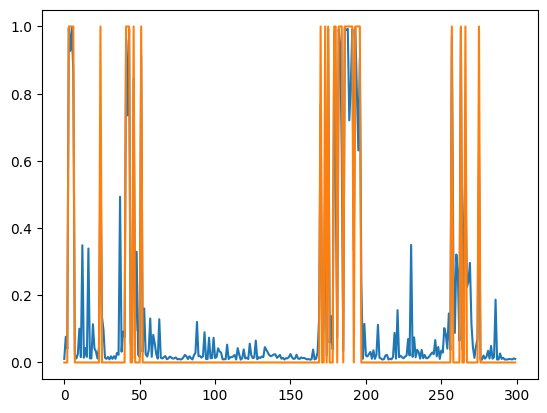

In [13]:
plt.plot(predictions_3[:300])
plt.plot(pred_classes[:300])

In [24]:
def len_cont_labels(pred_classes):
    # compute the length of the predictions
    change_points = np.diff(pred_classes) != 0
    # Indices where runs end
    run_ends = np.where(change_points)[0] + 1

    # Add start and end to split
    run_lengths = np.diff(np.r_[0, run_ends, len(pred_classes)])
    return run_lengths

(array([2.044e+03, 8.500e+01, 6.600e+01, 4.700e+01, 2.700e+01, 1.600e+01,
        1.700e+01, 6.000e+00, 1.000e+01, 1.000e+01, 6.000e+00, 5.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([  1. ,  18.5,  36. ,  53.5,  71. ,  88.5, 106. , 123.5, 141. ,
        158.5, 176. , 193.5, 211. , 228.5, 246. , 263.5, 281. , 298.5,
        316. , 333.5, 351. , 368.5, 386. , 403.5, 421. , 438.5, 456. ,
        473.5, 491. , 508.5, 526. ]),
 <BarContainer object of 30 artists>)

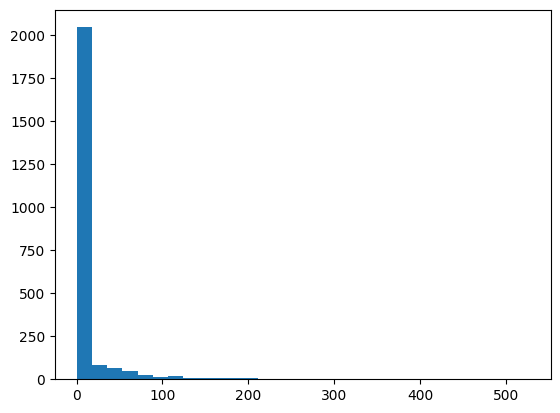

In [25]:
plt.hist(len_cont_labels(pred_classes), bins=30)

Testing applying a smoothing in the predictions

In [ ]:
# sliding window, gaussian, std = 1 
from scipy.signal.windows import gaussian
def gaussian_moving_average(probs, window_size=10, std=1.0):
    """
    Smooth a sequence of probabilities using a Gaussian-weighted moving average.
    
    Args:
        probs (list or np.array): sequence of probabilities
        window_size (int): number of points in the window
        std (float): standard deviation of the Gaussian

    Returns:
        np.array: smoothed sequence
    """
    # Generate Gaussian weights
    weights = gaussian(window_size, std=std)
    weights /= weights.sum()  # normalize to sum to 1
    
    # Apply weighted moving average
    full = np.convolve(probs, weights, mode='full')
    start = (len(weights) - 1) // 2
    end = start + len(probs)

    smoothed = full[start:end]
    return smoothed

def moving_average(probs, window=3):
    smoothed = np.convolve(probs, np.ones(window)/window, mode='same')
    return smoothed

def sequential_smoothing(probs, alpha=0.7):
    """
    exponential smoothing
    Adjusts the current probability based on the previous one.
    P_smooth = (alpha * current_prob) + ((1 - alpha) * previous_prob)
    """
    smoothed_probs = np.zeros_like(probs)
    smoothed_probs[0] = probs[0] # First one stays the same
    
    for t in range(1, len(probs)):
        smoothed_probs[t] = (alpha * probs[t]) + ((1 - alpha) * smoothed_probs[t-1])
    
    return smoothed_probs

In [146]:
pred_smoothed = gaussian_moving_average(predictions_3, window_size=5, std=20)
pred_smoothed = moving_average(predictions_3, window=10) 
# pred_smoothed = sequential_smoothing(predictions_3, alpha=0.3)

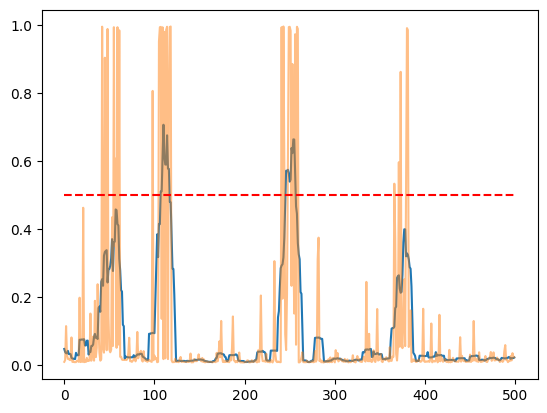

In [148]:
i = 500
plt.plot(pred_smoothed[i:i+500])
plt.plot(predictions_3[i:i+500], alpha=0.5)
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
# plt.plot(np.where(pred_smoothed > 0.5, 1, 0)[i:i+500])
# plt.plot(np.where(predictions_3 > 0.5, 1, 0)[i:i+ 500])

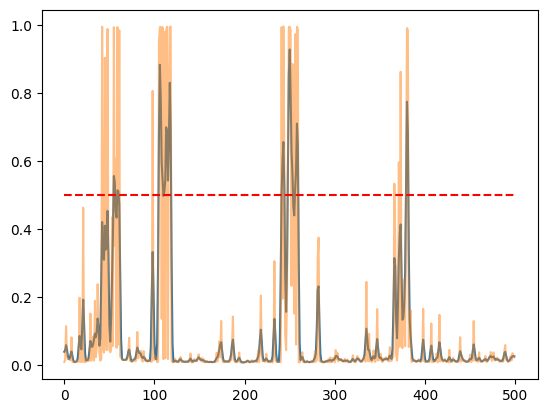

In [101]:
i = 500
plt.plot(pred_smoothed[i:i+500])
plt.plot(predictions_3[i:i+500], alpha=0.5)
plt.hlines(0.5, xmin=0, xmax=500, colors='red', linestyles='dashed')
# plt.plot(np.where(pred_smoothed > 0.5, 1, 0)[i:i+500])
# plt.plot(np.where(predictions_3 > 0.5, 1, 0)[i:i+ 500])

(array([248.,  46.,  23.,  20.,   9.,  12.,   2.,   2.,   1.,   4.,   1.,
          0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([1.00000000e+00, 5.30666667e+01, 1.05133333e+02, 1.57200000e+02,
        2.09266667e+02, 2.61333333e+02, 3.13400000e+02, 3.65466667e+02,
        4.17533333e+02, 4.69600000e+02, 5.21666667e+02, 5.73733333e+02,
        6.25800000e+02, 6.77866667e+02, 7.29933333e+02, 7.82000000e+02,
        8.34066667e+02, 8.86133333e+02, 9.38200000e+02, 9.90266667e+02,
        1.04233333e+03, 1.09440000e+03, 1.14646667e+03, 1.19853333e+03,
        1.25060000e+03, 1.30266667e+03, 1.35473333e+03, 1.40680000e+03,
        1.45886667e+03, 1.51093333e+03, 1.56300000e+03]),
 <BarContainer object of 30 artists>)

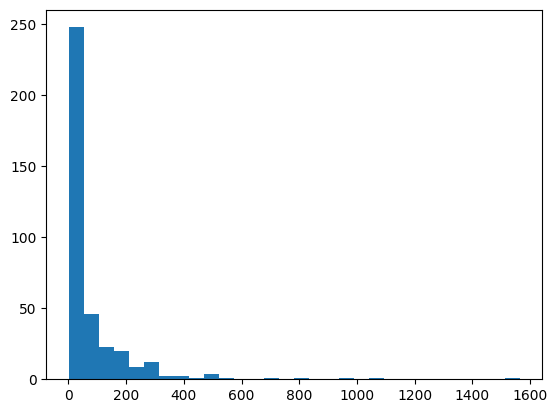

In [149]:
plt.hist(len_cont_labels(np.where(pred_smoothed > 0.5, 1, 0)), bins=30)

Checking the distribution for the class

In [151]:
pred_smoothed = moving_average(predictions_3, window=10) 
np.unique(np.where(pred_smoothed > 0.5, 1, 0), return_counts=True)

(array([0, 1]), array([25760,  1402]))

In [152]:
pred_smoothed = moving_average(predictions_3, window=5) 
np.unique(np.where(pred_smoothed > 0.5, 1, 0), return_counts=True)

(array([0, 1]), array([25462,  1700]))

In [154]:
pred_smoothed = gaussian_moving_average(predictions_3, window_size=5, std=2)
np.unique(np.where(pred_smoothed > 0.5, 1, 0), return_counts=True)

(array([0, 1]), array([25421,  1741]))

In [155]:
pred_smoothed = gaussian_moving_average(predictions_3, window_size=10, std=2)
np.unique(np.where(pred_smoothed > 0.5, 1, 0), return_counts=True)

(array([0, 1]), array([25514,  1648]))

In [156]:
predictions_3

array([0.01064204, 0.07662841, 0.04142172, ..., 0.01103186, 0.00852722,
       0.03276176], shape=(27162,))

In [159]:
save_submission(predictions_3, 3)

### Submission 4

We test the combination model : svm_rbf | tfidf_bigrams | no_lower

In [168]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)
final_stopwords_list = stopwords.words('french') 

prep = Preprocessing(low_case = False,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

model = SVC(
        kernel='rbf',
        max_iter=5000,
        random_state=42,
        probability=True
)

vectorizer = build_vectorizer(name="tfidf", stop_words=final_stopwords_list, 
                            max_features=5000, preprocessor=prep,
                            ngram_range=(1,1))

In [169]:
# train on all X_train
vect_train = vectorizer.fit_transform(alltxt)
vect_test = vectorizer.transform(alltxt_test)

In [170]:
model.fit(vect_train, alllabs)

y_pred_train = model.predict(vect_train)
ypred_train_prob = model.predict_proba(vect_train) # probas for AUC

y_pred = model.predict(vect_test)
y_pred_prob = model.predict_proba(vect_test)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [171]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score

print("Train metrics")
print("Average Precision (Macro):", average_precision_score(alllabs, ypred_train_prob[:, 1], average="macro"))
print("F1 Score (Macro):", f1_score(alllabs, y_pred_train, average="macro"))
print("Precision (Macro):", precision_score(alllabs, y_pred_train, average="macro"))
print("Recall (Macro):", recall_score(alllabs, y_pred_train, average="macro"))
print("ROC AUC (Macro):", roc_auc_score(alllabs, ypred_train_prob[:, 1]))

Train metrics
Average Precision (Macro): 0.48419395188421405
F1 Score (Macro): 0.6876241343032183
Precision (Macro): 0.6927113447041573
Recall (Macro): 0.682973750545764
ROC AUC (Macro): 0.7432992993997936


Visualising predictions labels and distributions

(array([0, 1]), array([57396,    17]))


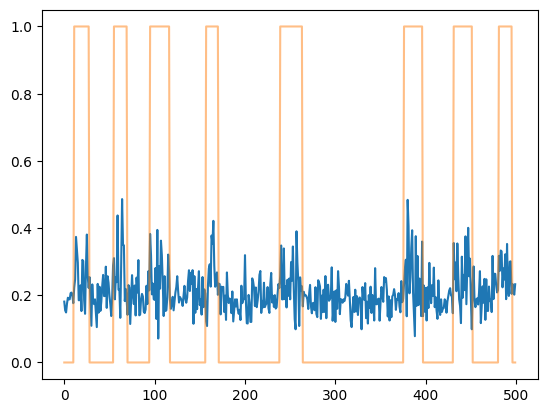

In [185]:
plt.plot(ypred_train_prob[:, 1][:500])
plt.plot(alllabs[:500], alpha=0.5)
print(np.unique(np.where(ypred_train_prob[:, 1] > 0.5, 1, 0), return_counts = True))

Using scaling as the model seemed to not have converged

In [176]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(vect_train)
X_test_scaled = scaler.transform(vect_test)

In [177]:
model.fit(X_train_scaled, alllabs)

y_pred_train_scaled = model.predict(X_train_scaled)
ypred_train_prob_scaled = model.predict_proba(X_train_scaled) # probas for AUC

y_pred_scaled = model.predict(X_test_scaled)
y_pred_prob_scaled = model.predict_proba(X_test_scaled)

/home/franciline/Documents/Master/M1/S2/RITAL/projet_TAL/tal-projet/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [178]:
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, precision_score, recall_score

print("Train metrics")
print("Average Precision (Macro):", average_precision_score(alllabs, ypred_train_prob_scaled[:, 1], average="macro"))
print("F1 Score (Macro):", f1_score(alllabs, y_pred_train_scaled, average="macro"))
print("Precision (Macro):", precision_score(alllabs, y_pred_train_scaled, average="macro"))
print("Recall (Macro):", recall_score(alllabs, y_pred_train_scaled, average="macro"))
print("ROC AUC (Macro):", roc_auc_score(alllabs, ypred_train_prob_scaled[:, 1]))

Train metrics
Average Precision (Macro): 0.4782724543758242
F1 Score (Macro): 0.6779833076538906
Precision (Macro): 0.6736333551383716
Recall (Macro): 0.6827623310163125
ROC AUC (Macro): 0.7249076933763118


(array([0]), array([57413]))


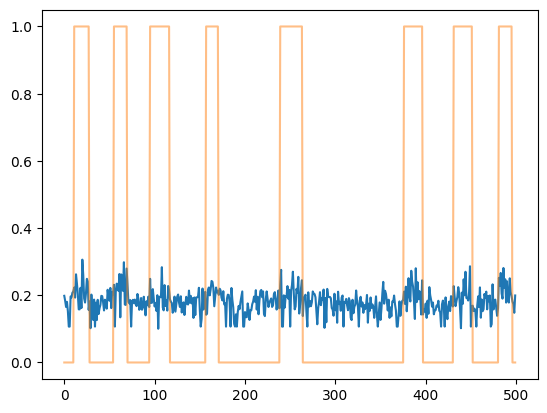

In [181]:
plt.plot(ypred_train_prob_scaled[:, 1][:500])
plt.plot(alllabs[:500], alpha=0.5)
print(np.unique(np.where(ypred_train_prob_scaled[:, 1] > 0.5, 1, 0), return_counts = True))

In [ ]:
# vocab = {'<PAD>': 0, '<UNK>': 1, 'SPACE': 2, 'ADP': 3, 'VERB_X': 4, 'DET': 5, 'ADJ': 6, 'NOUN': 7, 
#          'PUNCT': 8, 'CCONJ': 9, 'NUM': 10, 'PROPN': 11, 'PRON': 12, 'AUX': 13, 'VERB_Past': 14, 
#          'SCONJ': 15, 'VERB_Pres': 16, 'ADV': 17, 'VERB_Imp': 18, 'VERB_Fut': 19, 'X': 20, 'INTJ': 21, 'SYM': 22}
# len(vocab)